# CIFAR-10 Dataset - Model Comparison

## Poredjenje 5 razlicitih konfiguracija modela

Ovaj notebook trenira i poredi 5 razlicitih modela kroz:
- Metricke vrednosti (po fold-u i prosecno)
- Learning curves 
- Confusion matrix
- Vreme treniranja i inferencije
- Velicinu modela i resurse

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import tensorflow as tf 
from tensorflow import keras
import time
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from model_arhitecture import CIFAR10CNN
from train_model import CIFAR10Trainer
from sklearn.metrics import confusion_matrix

print(f"TensorFlow version: {tf.__version__}")
print("Biblioteke učitane")

TensorFlow version: 2.10.0
Biblioteke učitane


### Definisanje 5 razlicitih konfiguracija

In [2]:
from model_comparison import ModelComparator, MODEL_CONFIGS

print("Definisane konfiguracije:\n")
for name, config in MODEL_CONFIGS.items():
    print(f"{name}:")
    for key, value in config.items():
        print(f"  {key}: {value}")
    print()

Definisane konfiguracije:

Model_1_Baseline:
  num_conv_blocks: 3
  filters: [32, 64, 128]
  kernel_size: 3
  dense_units: 256
  dropout_rate: 0.5
  learning_rate: 0.001

Model_2_Deep:
  num_conv_blocks: 4
  filters: [32, 64, 128, 256]
  kernel_size: 3
  dense_units: 512
  dropout_rate: 0.5
  learning_rate: 0.001

Model_3_Wide:
  num_conv_blocks: 3
  filters: [64, 128, 256]
  kernel_size: 3
  dense_units: 512
  dropout_rate: 0.5
  learning_rate: 0.001

Model_4_Small:
  num_conv_blocks: 2
  filters: [32, 64]
  kernel_size: 3
  dense_units: 128
  dropout_rate: 0.3
  learning_rate: 0.001

Model_5_LargeKernel:
  num_conv_blocks: 3
  filters: [32, 64, 128]
  kernel_size: 5
  dense_units: 256
  dropout_rate: 0.5
  learning_rate: 0.0005



### Ucitavanje podataka

In [3]:
trainer = CIFAR10Trainer(experiment_name='cifar10_comparison')
X, y = trainer.load_data(max_samples=10000)  

print(f"\nShape podataka: X={X.shape}, y={y.shape}")

Verzije biblioteka logovane u logs/environment.json
Učitavanje podataka...


Učitavanje slika: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:13<00:00, 752.13it/s]


  Učitano 10000 slika
  Shape: (10000, 32, 32, 3)
  Labels: (10000,)

Shape podataka: X=(10000, 32, 32, 3), y=(10000,)


### Treniranje svih modela

Trajanje 30-60 minuta.

In [4]:
comparator = ModelComparator(classes=trainer.classes)

for model_name, config in MODEL_CONFIGS.items():
    result = comparator.train_and_evaluate_model(
        X, y,
        config=config,
        model_name=model_name,
        n_folds=5,
        epochs=30,
        batch_size=64
    )

print("\nSvi modeli trenirani!")


Treniranje: Model_1_Baseline

Fold 1/5
Val Acc: 0.7220, Train Time: 478.89s

Fold 2/5
Val Acc: 0.7275, Train Time: 579.69s

Fold 3/5
Val Acc: 0.7325, Train Time: 622.70s

Fold 4/5
Val Acc: 0.7295, Train Time: 626.73s

Fold 5/5
Val Acc: 0.7310, Train Time: 581.90s

Model_1_Baseline završen!
  Avg Val Acc: 0.7285 ± 0.0036
  Avg Train Time: 577.98s
  Model Size: 816,938 params (3.12 MB)

Treniranje: Model_2_Deep

Fold 1/5
Val Acc: 0.7040, Train Time: 627.92s

Fold 2/5
Val Acc: 0.7465, Train Time: 755.93s

Fold 3/5
Val Acc: 0.6865, Train Time: 572.90s

Fold 4/5
Val Acc: 0.7300, Train Time: 739.44s

Fold 5/5
Val Acc: 0.7330, Train Time: 695.14s

Model_2_Deep završen!
  Avg Val Acc: 0.7200 ± 0.0217
  Avg Train Time: 678.27s
  Model Size: 1,708,074 params (6.52 MB)

Treniranje: Model_3_Wide

Fold 1/5
Val Acc: 0.7065, Train Time: 903.93s

Fold 2/5
Val Acc: 0.7165, Train Time: 992.84s

Fold 3/5
Val Acc: 0.7025, Train Time: 904.59s

Fold 4/5
Val Acc: 0.6845, Train Time: 901.77s

Fold 5/5
Val Ac

### Tabela poredjenja

In [5]:
comparison_df = comparator.create_comparison_table()
print("\nPOREĐENJE MODELA:")
print("="*100)
display(comparison_df)

comparison_df.to_csv('logs/model_comparison_table.csv', index=False)
print("\nTabela sačuvana")


POREĐENJE MODELA:


,Model,Val Accuracy,Val Loss,Train Time (s),Inference Time (s),Params,Memory (MB)
0,Model_1_Baseline,0.7285 ± 0.0036,0.8554,577.98,1.7769,"816,938",3.12
1,Model_2_Deep,0.7200 ± 0.0217,1.0214,678.27,2.1849,"1,708,074",6.52
2,Model_3_Wide,0.7113 ± 0.0204,0.9694,1015.58,3.0529,"3,253,834",12.41
3,Model_4_Small,0.6491 ± 0.0145,1.0913,306.55,1.3010,"592,554",2.26
4,Model_5_LargeKernel,0.6921 ± 0.0138,0.9911,1063.79,2.6065,"1,326,378",5.06



Tabela sačuvana


### Vizualizacija poredjenja

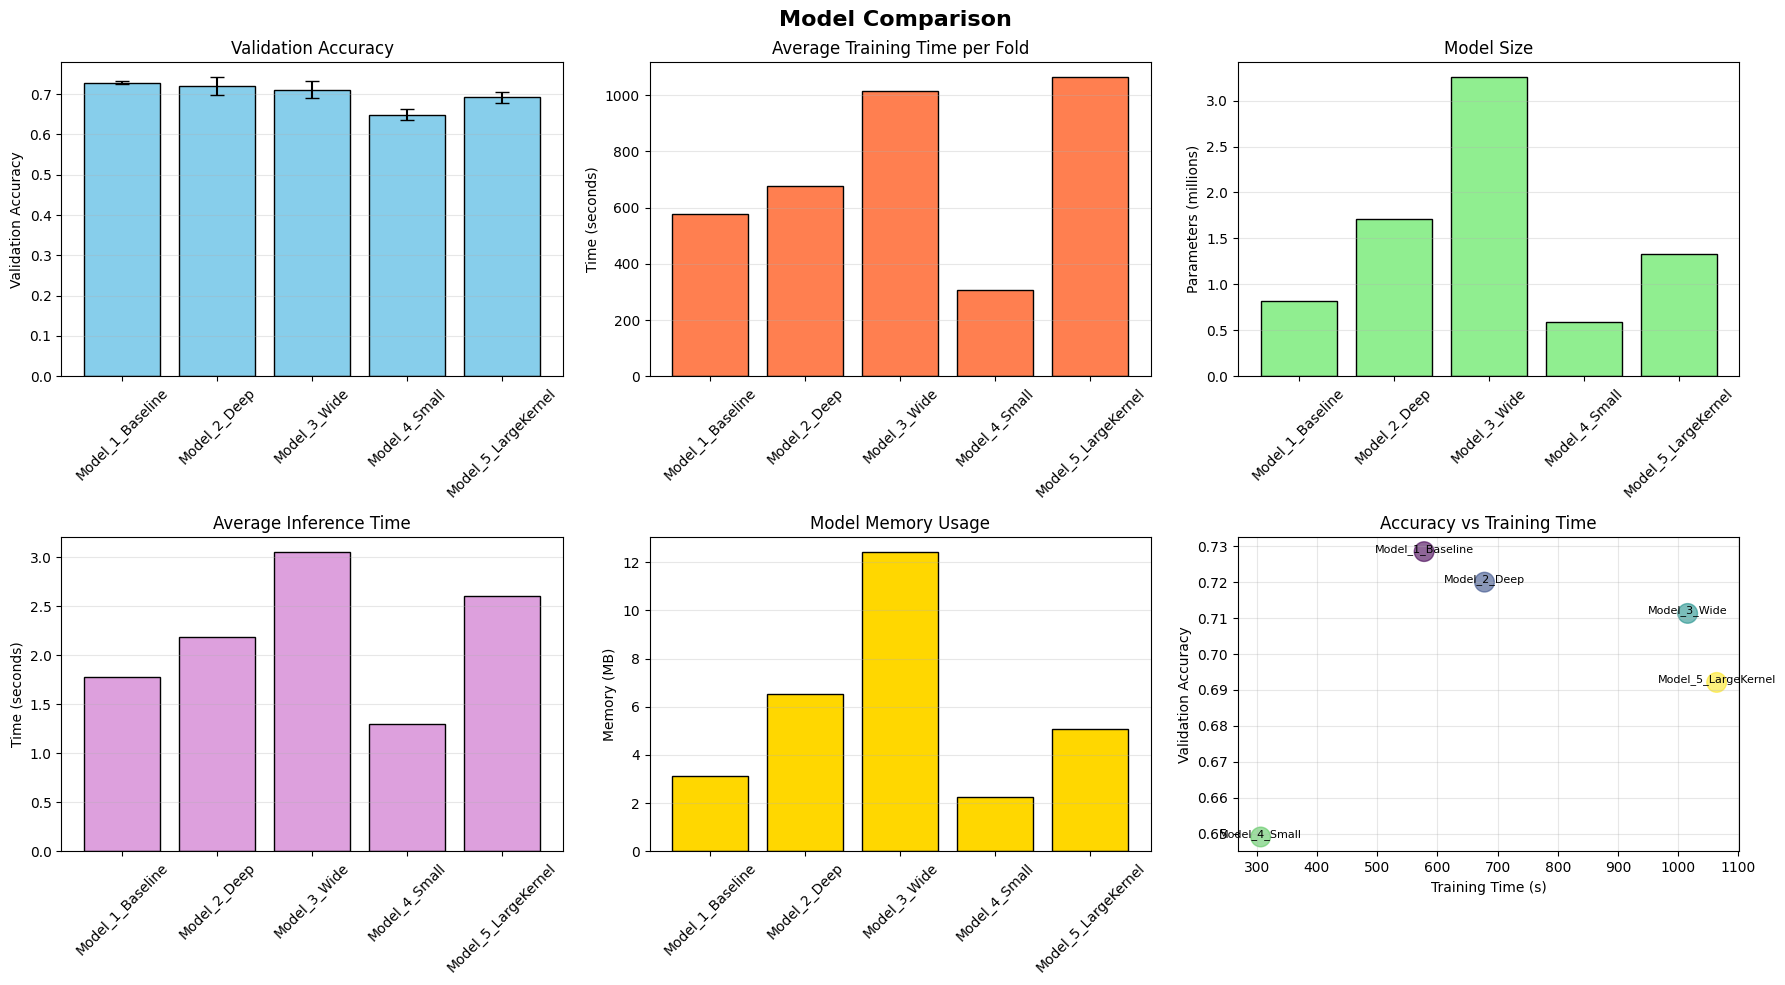

In [6]:
comparator.plot_comparison()

### Learning Curves

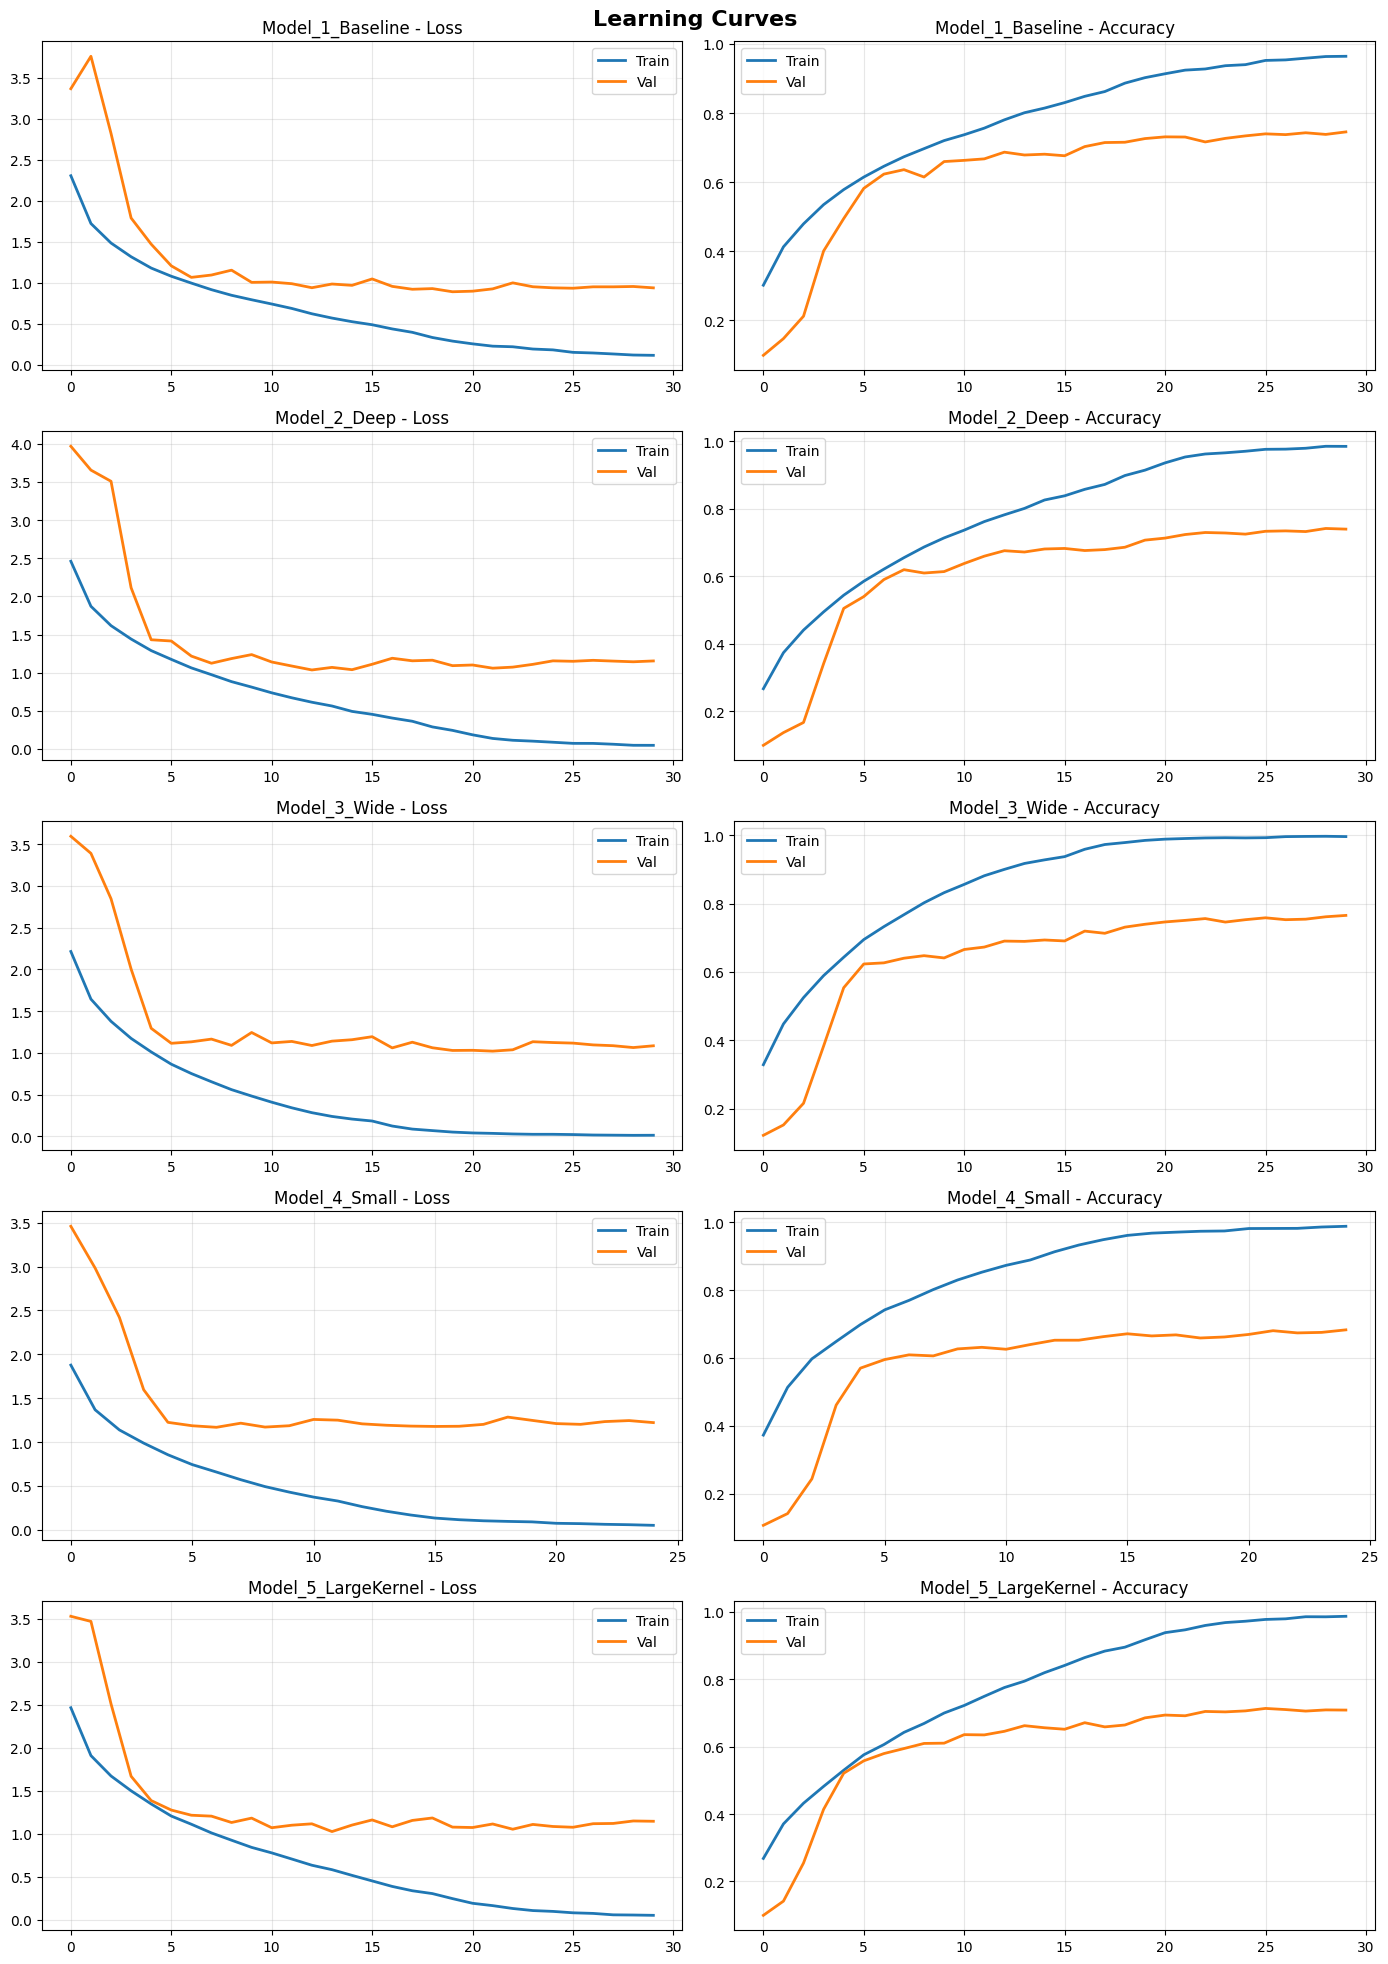

In [7]:
fig, axes = plt.subplots(len(MODEL_CONFIGS), 2, figsize=(14, 4*len(MODEL_CONFIGS)))
fig.suptitle('Learning Curves', fontsize=16, fontweight='bold')

for idx, result in enumerate(comparator.results):
    histories = result['fold_histories']
    max_epochs = max([len(h['loss']) for h in histories])
    
    avg_loss, avg_val_loss = [], []
    avg_acc, avg_val_acc = [], []
    
    for epoch in range(max_epochs):
        losses = [h['loss'][epoch] for h in histories if epoch < len(h['loss'])]
        val_losses = [h['val_loss'][epoch] for h in histories if epoch < len(h['val_loss'])]
        accs = [h['accuracy'][epoch] for h in histories if epoch < len(h['accuracy'])]
        val_accs = [h['val_accuracy'][epoch] for h in histories if epoch < len(h['val_accuracy'])]
        
        avg_loss.append(np.mean(losses))
        avg_val_loss.append(np.mean(val_losses))
        avg_acc.append(np.mean(accs))
        avg_val_acc.append(np.mean(val_accs))
    
    axes[idx, 0].plot(avg_loss, label='Train', linewidth=2)
    axes[idx, 0].plot(avg_val_loss, label='Val', linewidth=2)
    axes[idx, 0].set_title(f"{result['model_name']} - Loss")
    axes[idx, 0].legend()
    axes[idx, 0].grid(alpha=0.3)
    
    axes[idx, 1].plot(avg_acc, label='Train', linewidth=2)
    axes[idx, 1].plot(avg_val_acc, label='Val', linewidth=2)
    axes[idx, 1].set_title(f"{result['model_name']} - Accuracy")
    axes[idx, 1].legend()
    axes[idx, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('logs/learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

### Confusion Matrix

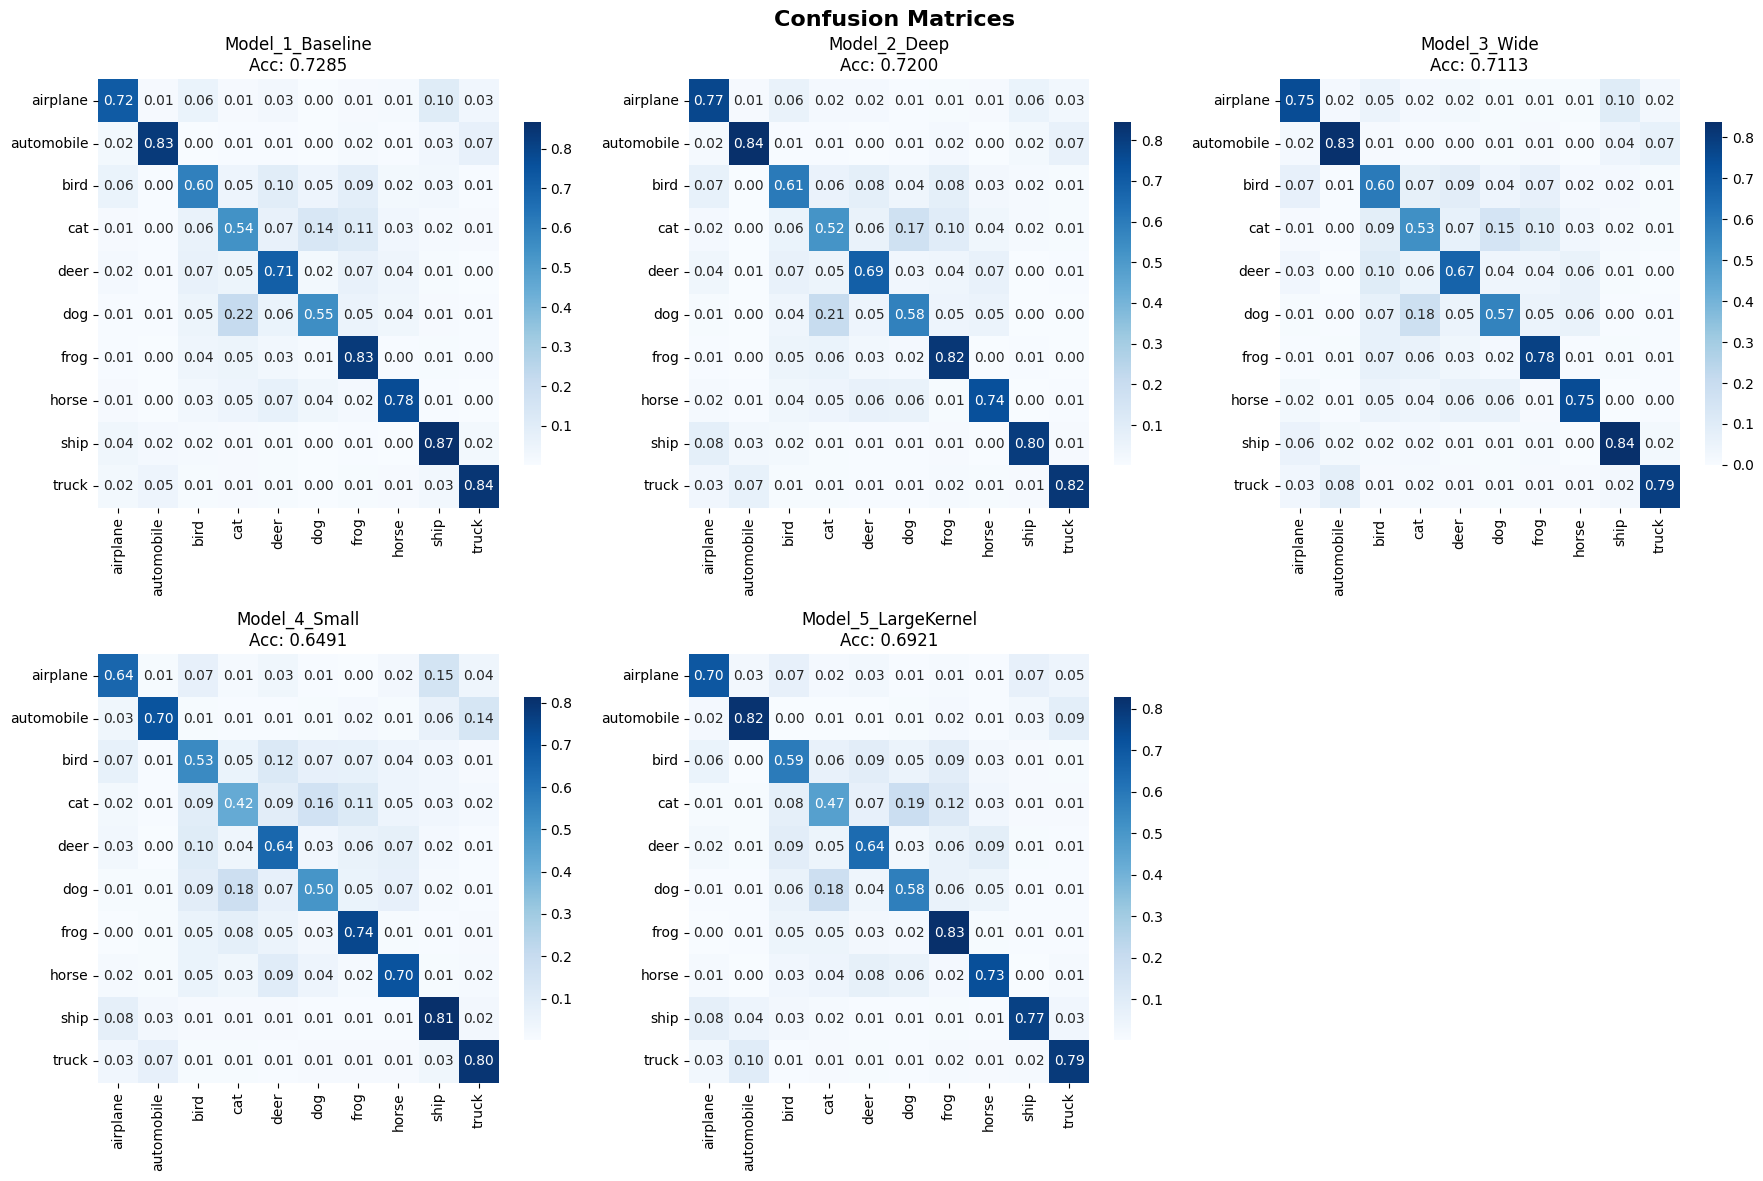

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, result in enumerate(comparator.results):
    avg_cm = np.mean(result['confusion_matrices'], axis=0)
    avg_cm_norm = avg_cm / avg_cm.sum(axis=1, keepdims=True)
    
    sns.heatmap(avg_cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=trainer.classes, yticklabels=trainer.classes,
                ax=axes[idx], cbar_kws={'shrink': 0.8})
    axes[idx].set_title(f"{result['model_name']}\nAcc: {result['avg_val_accuracy']:.4f}")

if len(comparator.results) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig('logs/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

### ROC i PR krive (za najbolji model)

Kreiranje ROC/PR krivih za: Model_1_Baseline
63/63 [==============================] - 2s 30ms/step


<Figure size 1200x800 with 0 Axes>

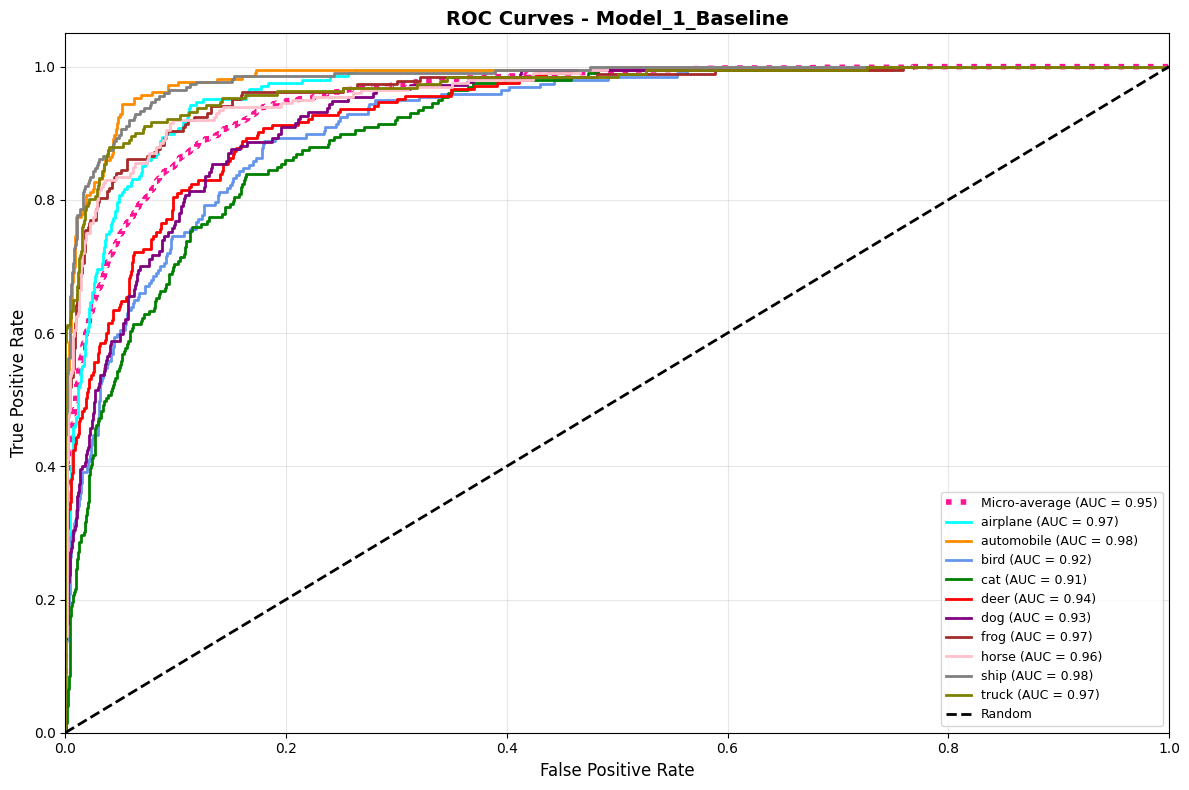

<Figure size 1200x800 with 0 Axes>

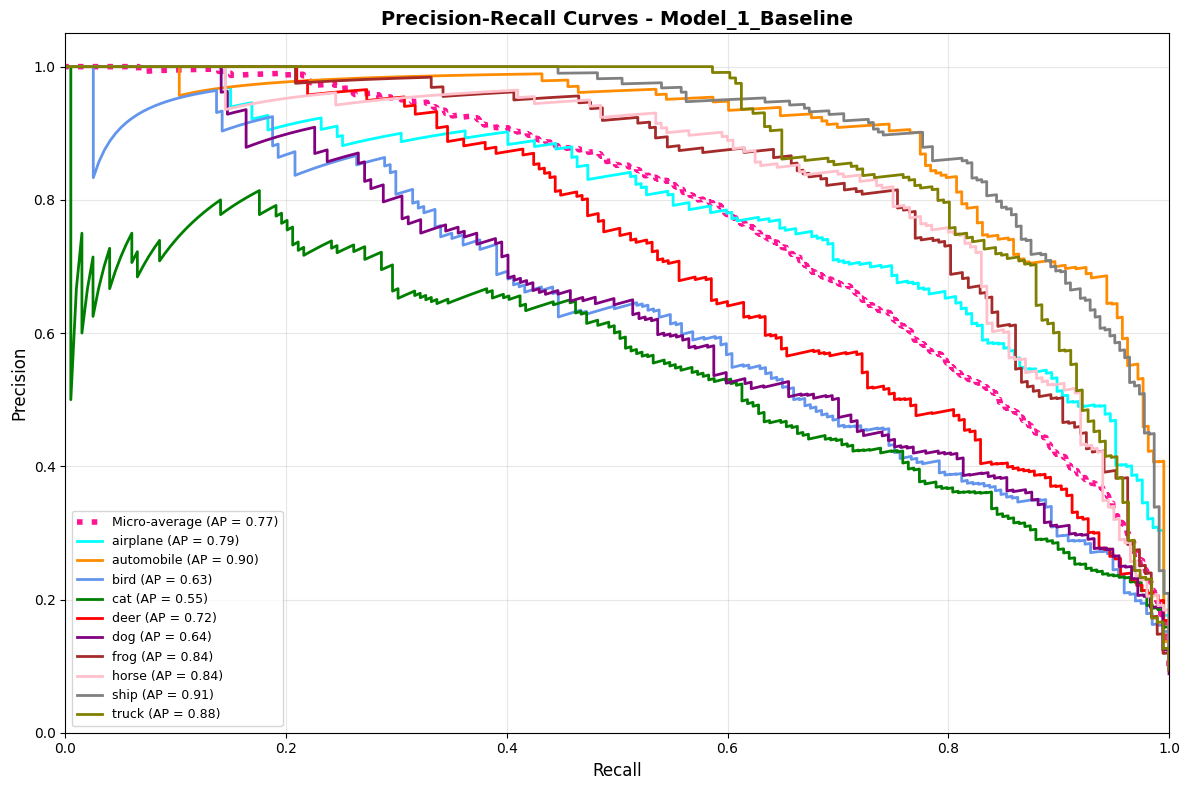


ROC/PR krive kreirane za Model_1_Baseline


In [9]:
from evaluation_metrics import plot_roc_curves, plot_pr_curves

#Uzimanje najboljeg modela
best_model = max(comparator.results, key=lambda x: x['avg_val_accuracy'])
print(f"Kreiranje ROC/PR krivih za: {best_model['model_name']}")

#Treniranje ponovo najbolji model da se dobiju predikcije
cnn = CIFAR10CNN()
model = cnn.build_custom_model(best_model['config'])
cnn.compile_model(learning_rate=best_model['config']['learning_rate'])

#Split podataka
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

#Treniranje
model.fit(X_train, y_train, epochs=10, batch_size=64, verbose=0)

#Predikcije
y_pred_proba = model.predict(X_val)

#ROC krive
plt.figure(figsize=(12, 8))
roc_auc = plot_roc_curves(y_val, y_pred_proba, trainer.classes, best_model['model_name'])
plt.savefig('logs/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

#PR krive
plt.figure(figsize=(12, 8))
avg_precision = plot_pr_curves(y_val, y_pred_proba, trainer.classes, best_model['model_name'])
plt.savefig('logs/pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nROC/PR krive kreirane za {best_model['model_name']}")

### Cuvanje rezultata

In [10]:
comparator.save_results('model_comparison_results.json')
print("\nRezultati sačuvani")


Rezultati sačuvani u: logs\model_comparison_results.json

Rezultati sačuvani
